# Interactive noise playground

Weeeee I love noisy play!

In [1]:
from matplotlib import pyplot as plt
import numpy as np
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append("src/forest_gen")


In [3]:
from heightmap import normalized_noise2

## POS classifier from forrest_gen/scene.py

def classify_terrain(x: float, y: float) -> str:
    """Classify the terrain based on the x and y coordinates.

    Args:
        x (float): The x coordinate.
        y (float): The y coordinate.

    Returns:
        str: The classification of the terrain.
    """
    if normalized_noise2(x, y) > 0.5:
        return "forest"
    return "plain"



In [4]:
width = 25
height = 25
resolution = 500

x = np.linspace(0, width, resolution)
y = np.linspace(0, height, resolution)
xx, yy = np.meshgrid(x, y)

vec_classify = np.vectorize(classify_terrain)
terrain = vec_classify(xx, yy)

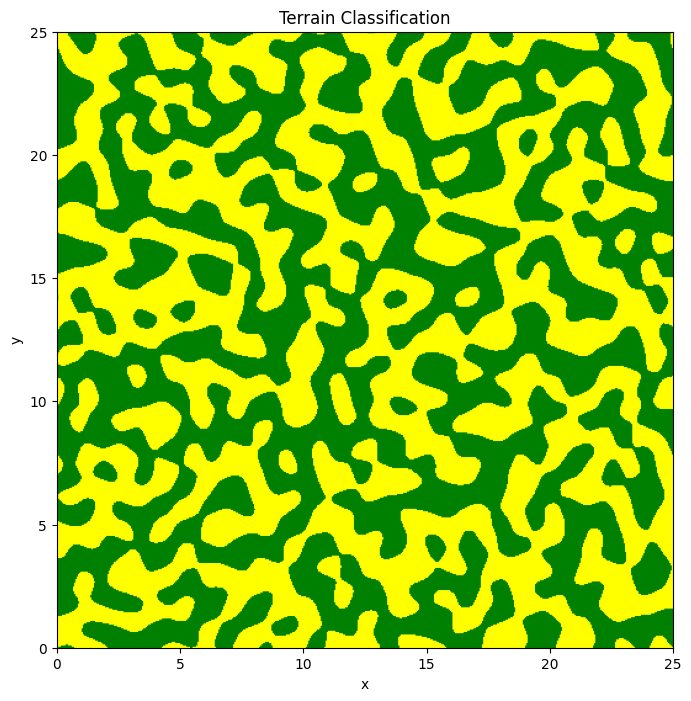

In [5]:
terrain_map = {"forest": 0, "plain": 1}
terrain_int = np.vectorize(terrain_map.get)(terrain)

from matplotlib.colors import ListedColormap
cmap = ListedColormap(["green", "yellow"])

plt.figure(figsize=(8, 8))
plt.imshow(terrain_int, origin="lower", extent=(x.min(), x.max(), y.min(), y.max()), cmap=cmap)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Terrain Classification")
plt.show()

In [ ]:
from asset_dist import grass_points

grass_plain = grass_points(width, height, 0.2)
grass_forest = grass_points(width, height, 0.5)


def gras_distribution(grass_plain, grass_forest):
    """Distribute grass points based on terrain classification.

    Args:
        grass_plain (list): List of grass points in plain terrain.
        grass_forest (list): List of grass points in forest terrain.
        *more will be added ig*

    Returns:
        list: List of distributed grass points.
    """
    grass_end = []
    for item in grass_plain:
        if classify_terrain(item[0], item[1]) == "plain":
            grass_end.append(item)
    for item in grass_forest:
        if classify_terrain(item[0], item[1]) == "forest":
            grass_end.append(item)
    return grass_end

grass_final = gras_distribution(grass_plain, grass_forest)

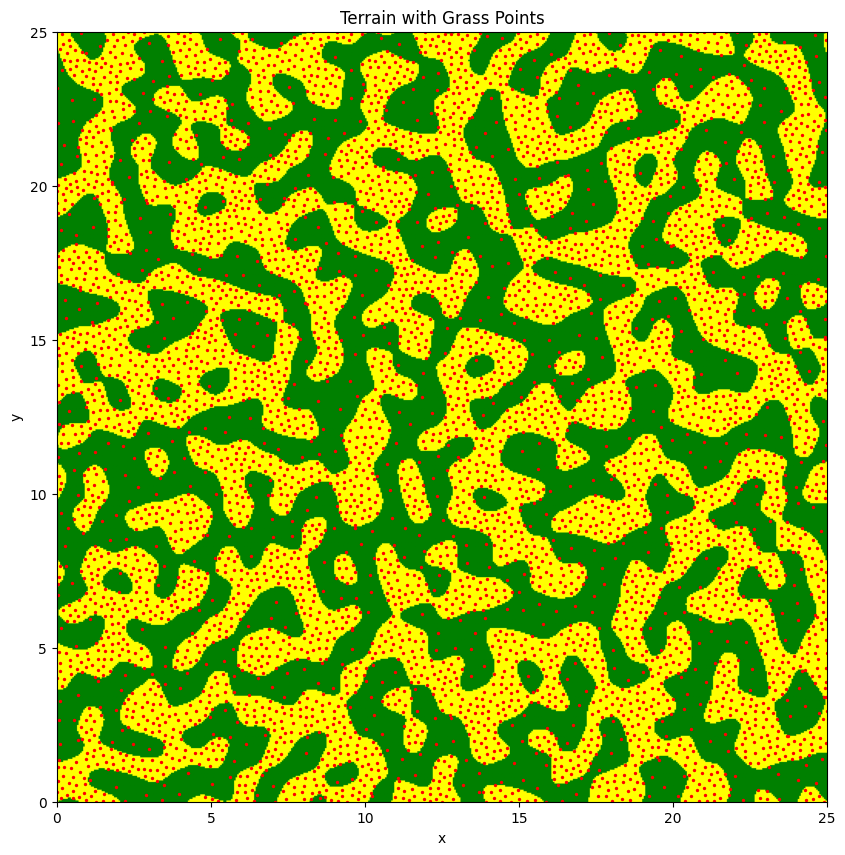

In [7]:
grass_x, grass_y = zip(*grass_final) if grass_final else ([], [])

plt.figure(figsize=(10, 10))
plt.imshow(terrain_int, origin="lower", extent=(x.min(), x.max(), y.min(), y.max()), cmap=cmap)
plt.scatter(grass_x, grass_y, s=2, c="red")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Terrain with Grass Points")
plt.show()